# Task 1
Lukas Prader

<Axes: xlabel='day'>

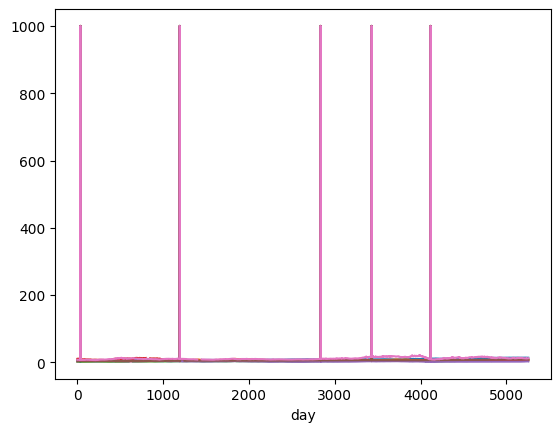

In [146]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os


data = pd.read_csv("../spiff_data-2.csv", index_col=0)
data = data.set_index('day')

data.plot(legend=False)

days with data anomaly:


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
36,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
1194,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
2836,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
3430,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
4118,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0


new values:


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
36,6.290170,2.842251,2.064018,8.970266,3.606918,3.985158,7.434838
1194,6.838924,5.584437,3.418999,8.763320,3.313187,4.700909,10.321043
2836,9.230156,4.855965,3.850422,6.238832,2.075396,5.889229,10.410045
3430,9.046035,6.818339,4.926725,5.114866,3.304403,6.213680,18.912905
4118,11.417295,4.976386,3.039544,4.585574,1.742467,6.702207,10.047680


variances of the neighboring values:


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
36,0.000658,0.000140,0.000038,0.017639,0.001195,0.000122,0.000818
1194,0.000189,0.027081,0.000547,0.005388,0.006674,0.000010,0.000647
2836,0.002367,0.000009,0.001082,0.001152,0.000014,0.000041,0.000010
3430,0.000016,0.000015,0.000002,0.000311,0.000015,0.000035,0.064664
4118,0.002223,0.005589,0.000924,0.002042,0.000341,0.000085,0.024259


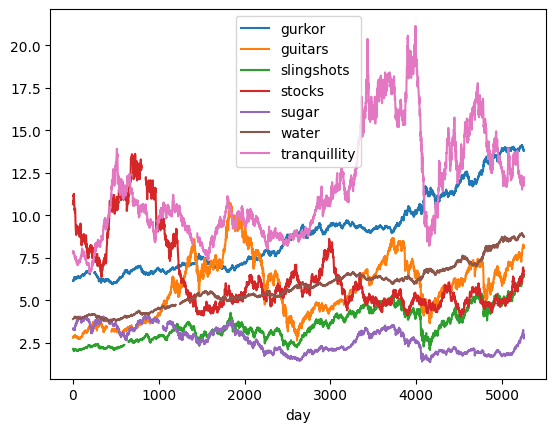

In [147]:
# replace values ==1000 with average of the two neighboring values
indices_1k = data[(data == 1000).any(axis=1)].index

print("days with data anomaly:")
display(data.loc[indices_1k])

data.loc[indices_1k] = (
    data.loc[indices_1k + 1].to_numpy() + data.loc[indices_1k - 1].to_numpy()
) / 2

print("new values:")
display(data.loc[indices_1k])

# get variance of the two neighboring values
interp_vars = np.stack(
    [data.loc[indices_1k - 1].to_numpy(), data.loc[indices_1k + 1].to_numpy()], axis=-1
).var(axis=-1)

# variance table with same index/columns format as data.loc[indices_1k]
interp_vars_df = pd.DataFrame(interp_vars, index=indices_1k, columns=data.columns)

print("variances of the neighboring values:")
display(interp_vars_df)

data.plot()

# Save the cleaned data to a new CSV file
os.makedirs("../augmented_data", exist_ok=True)
data.to_csv("../augmented_data/spiff_data_cleaned.csv")

Text(0, 0.5, 'day')

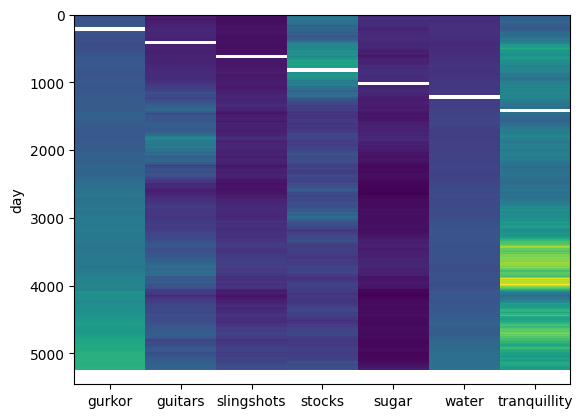

In [148]:
# Visualise the data as a heatmap to show missing value areas
plt.imshow(data, aspect="auto", cmap="viridis", interpolation="none")
plt.xticks(ticks=np.arange(data.shape[1]), labels=data.columns)
plt.ylabel("day")

What patterns exist within the individual series?

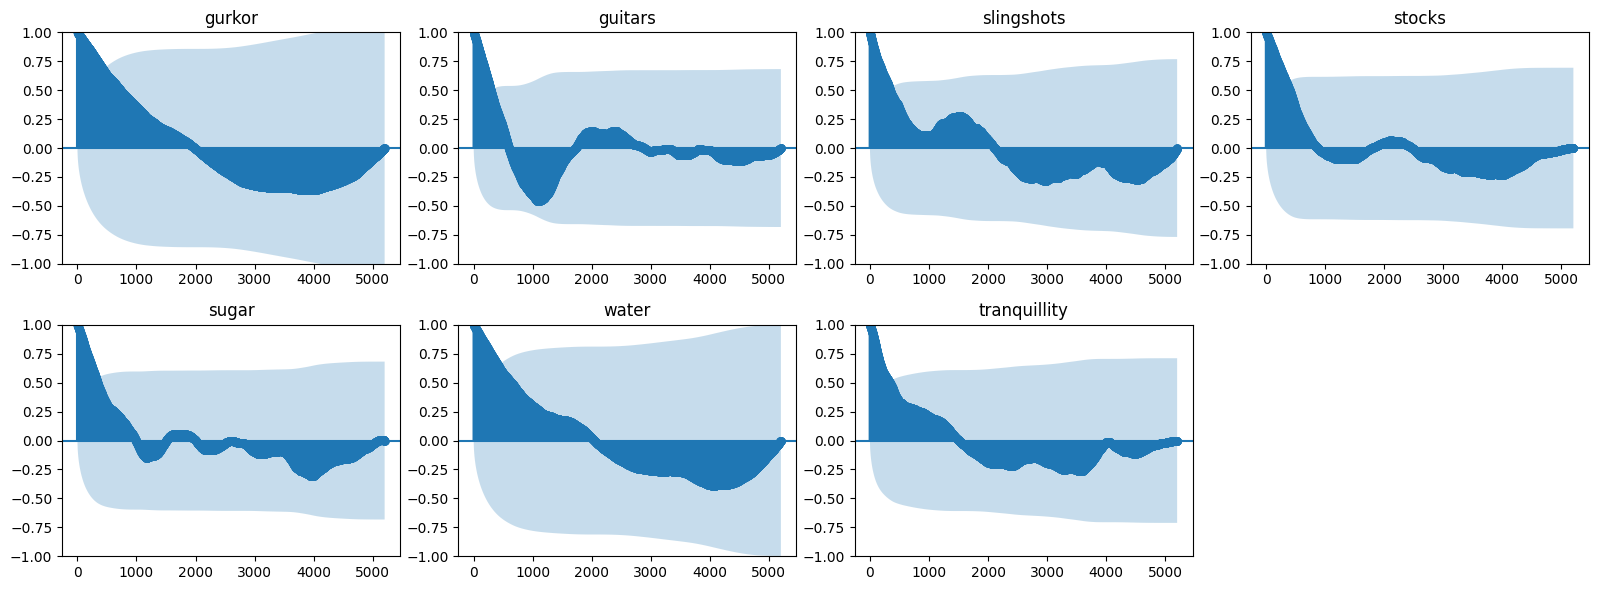

In [149]:
import statsmodels.api as sm

data_clean = pd.read_csv("../augmented_data/spiff_data_cleaned.csv", index_col="day")

fig, axes = plt.subplots(2, 4, figsize=(4 * 4, 3 * 2))
axes = axes.flatten()  # makes indexing easy for any nrows

for i, col_name in enumerate(data_clean.columns):
    data_usable = data_clean[col_name].dropna()
    sm.graphics.tsa.plot_acf(
        data_usable,
        lags=len(data_usable)-2,
        ax=axes[i],
        title=col_name
    )

# hide any unused panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()